In [1]:
import pandas as pd

# Load the dataset
data = pd.read_csv("Mall_Customers.csv")

# Preview the dataset
print(data.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [2]:
# Select relevant features for clustering
x = data.iloc[:, [3, 4]].values   # columns: Annual Income & Spending Score


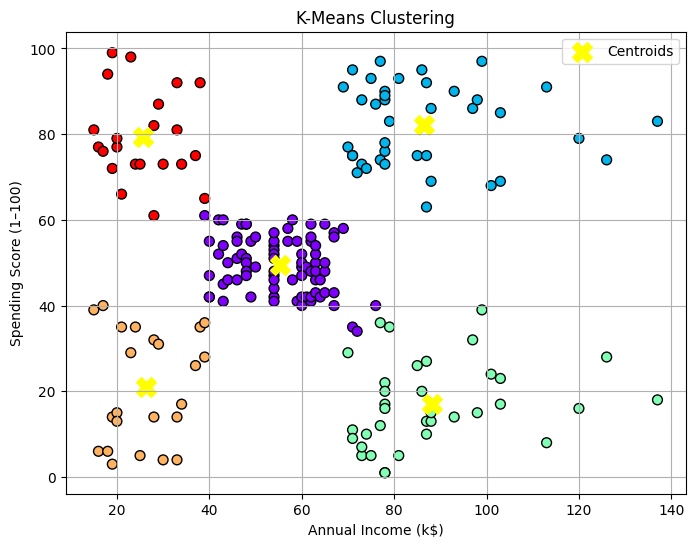

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create KMeans model
kmeans = KMeans(n_clusters=5, random_state=0)

# Fit and predict
k_labels = kmeans.fit_predict(x)

# Plot the clusters
plt.figure(figsize=(8,6))
plt.scatter(x[:,0], x[:,1], c=k_labels, cmap='rainbow', s=50, edgecolors='black')

# Plot the centroids
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200, c='yellow', label='Centroids', marker='X')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.title('K-Means Clustering')
plt.legend()
plt.grid(True)
plt.show()


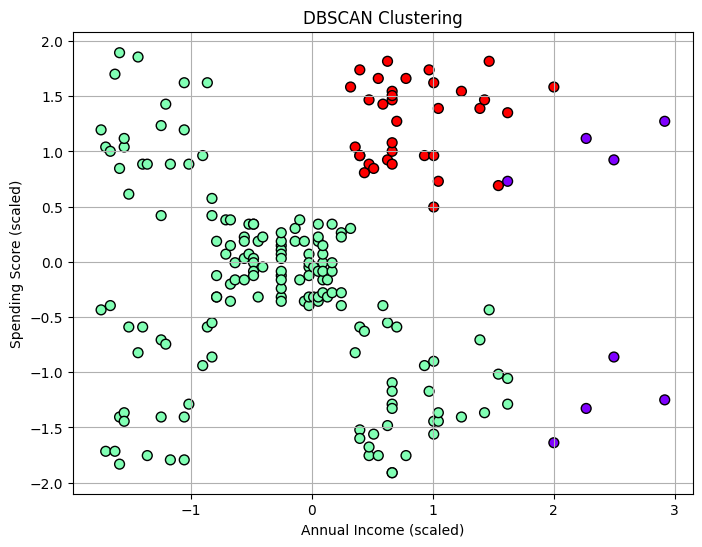

In [4]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Scale the data (important for DBSCAN)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Create DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Fit and predict
db_labels = dbscan.fit_predict(x_scaled)

# Plot the clusters
plt.figure(figsize=(8,6))
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=db_labels, cmap='rainbow', s=50, edgecolors='black')

plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('DBSCAN Clustering')
plt.grid(True)
plt.show()


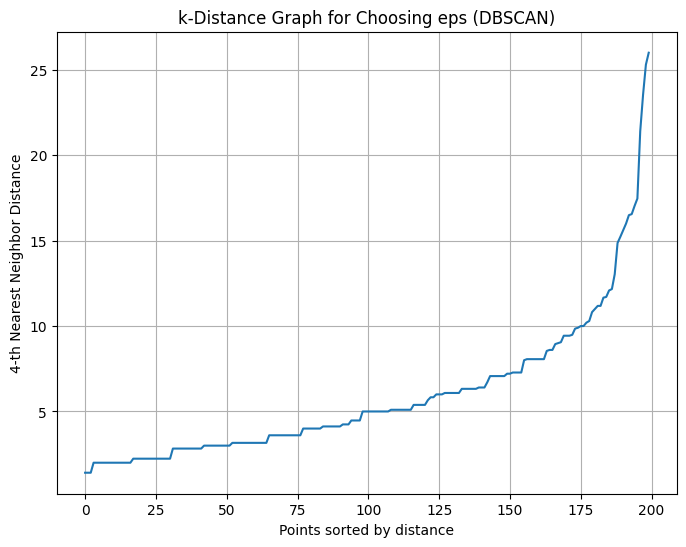

In [5]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("Mall_Customers.csv")
x = data.iloc[:, [3,4]].values   # Annual Income & Spending Score

# Compute distances to k-th nearest neighbor
k = 4  # typically min_samples - 1
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(x)
distances, indices = neighbors_fit.kneighbors(x)

# Sort and plot the k-distance graph
distances = np.sort(distances[:,k-1])

plt.figure(figsize=(8,6))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-th Nearest Neighbor Distance')
plt.title('k-Distance Graph for Choosing eps (DBSCAN)')
plt.grid(True)
plt.show()